# MRR Ze Frequency Profiles

Produces vertical profiles of the frequency of equivalent reflectivity factor (Ze) ≥ 5 dBZ$_e$ for three precipitation event types (S/SWIVT, Frontal, NW Postfrontal) at Alta and Highland MRR sites.

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** 12 June 2024

## Imports

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import math
from MRR_functions import open_ds

## Configuration

Set data paths, the Ze threshold, and range-gate trimming parameters.

In [4]:
# Path to pre-processed MRR netCDF files (Must have already run Generate_MRR_Datasets.py)
data_path = 'Data/MRR/'

# Directory for saved figures
fig_dir = 'Fig/'

# Reflectivity threshold (dBZe)
Ze_max = 5

# Range gates to drop at the bottom and top (poor data)
range_gate_start = 3
range_gate_end = -1


## Functions

In [5]:
def calc_frequency(ds_180_Alta, ds_30_Alta, ds_180_Highland, ds_30_Highland, Ze_max=5):
    """
    Calculate the frequency of Ze >= Ze_max (%) at each height gate and merge
    the 30-m (near-surface) and 180-m (upper) range-gate profiles.

    Due to radar toggling between 30-m and 180-m modes, the number of samples
    may differ between sites and range-gate intervals, so each site is
    normalised by its own sample count.
    """
    def _freq(ds, dim='height_ASL'):
        n = ds.sizes['time']
        # Find values greater than Ze_max and convert to percent
        return np.array([(ds.Ze.sel({dim: h}).values >= Ze_max).sum() / n * 100
                         for h in ds[dim].values])

    # Determine frequencies
    alta180_freq    = _freq(ds_180_Alta)
    alta30_freq     = _freq(ds_30_Alta)
    highland180_freq = _freq(ds_180_Highland)
    highland30_freq  = _freq(ds_30_Highland)

    # Merge 30-m (below 810 m AGL) and 180-m (from 900 m AGL upward) profiles
    def _merge(freq30, freq180, hASL_30, hASL_180, h_30, h_180):
        freq   = np.concatenate([freq30[:mergetop30index + 1],   freq180[mergebottom180index:]])
        h_ASL  = np.concatenate([hASL_30[:mergetop30index + 1],  hASL_180[mergebottom180index:]])
        h_AGL  = np.concatenate([h_30[:mergetop30index + 1],     h_180[mergebottom180index:]])
        return freq, h_ASL, h_AGL

    # Compute merged datasets
    highland_freq, highland_hASL, highland_h = _merge(
        highland30_freq, highland180_freq,
        ds_30_Highland.height_ASL.values, ds_180_Highland.height_ASL.values,
        ds_30_Highland.height.values,     ds_180_Highland.height.values)

    alta_freq, alta_hASL, alta_h = _merge(
        alta30_freq, alta180_freq,
        ds_30_Alta.height_ASL.values, ds_180_Alta.height_ASL.values,
        ds_30_Alta.height.values,     ds_180_Alta.height.values)

    return highland_freq, highland_hASL, highland_h, alta_freq, alta_hASL, alta_h


## Load Data

In [6]:
# Load datasets for each event type
highland180_SIVT, highland30_SIVT, alta180_SIVT, alta30_SIVT = open_ds(data_path, 'SIVT')
highland180_FR,   highland30_FR,   alta180_FR,   alta30_FR   = open_ds(data_path, 'FR')
highland180_PF,   highland30_PF,   alta180_PF,   alta30_PF   = open_ds(data_path, 'PF')
highland180_ALL,  highland30_ALL,  alta180_ALL,  alta30_ALL   = open_ds(data_path, 'ALL')


In [7]:
# Find merge indices: top of 30-m data = 810 m AGL; bottom of 180-m data = 900 m AGL.
# 810 m is the best merge point — the upper half of that gate overlaps 15 m
# of the first 180-m gate, which is an acceptable trade-off.
mergetop30index    = int(np.where(alta30_SIVT.height == 810.)[0])
mergebottom180index = int(np.where(alta180_SIVT.height == 900.)[0])


In [8]:
# Calculate merged Ze >= Ze_max frequency profiles for each event type
highland_freq_SIVT, highland_hASL_SIVT, _, alta_freq_SIVT, alta_hASL_SIVT, _ = \
    calc_frequency(alta180_SIVT, alta30_SIVT, highland180_SIVT, highland30_SIVT, Ze_max)

highland_freq_FR,   highland_hASL_FR,   _, alta_freq_FR,   alta_hASL_FR,   _ = \
    calc_frequency(alta180_FR,   alta30_FR,   highland180_FR,   highland30_FR,   Ze_max)

highland_freq_PF,   highland_hASL_PF,   _, alta_freq_PF,   alta_hASL_PF,   _ = \
    calc_frequency(alta180_PF,   alta30_PF,   highland180_PF,   highland30_PF,   Ze_max)

highland_freq_ALL,   highland_hASL_ALL,   _, alta_freq_ALL,   alta_hASL_ALL,   _ = \
    calc_frequency(alta180_ALL,   alta30_ALL,   highland180_ALL,   highland30_ALL,   Ze_max)


## Plot for Synoptic Classifications

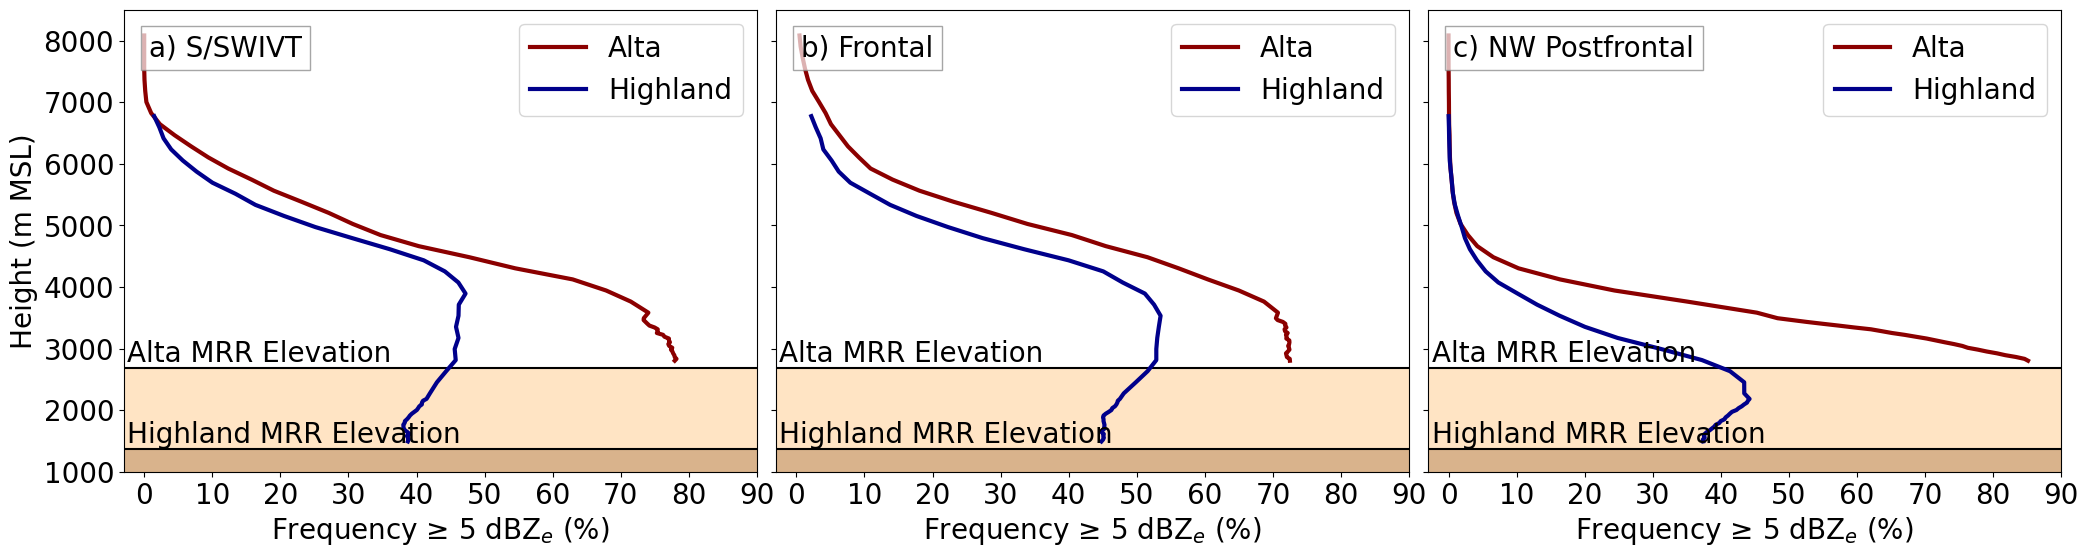

In [9]:
# Y-axis lower bound (m MSL)
bottom = 1000

# Panel definitions: (alta_freq, alta_hASL, highland_freq, highland_hASL, panel_label)
panels = [
    (alta_freq_SIVT, alta_hASL_SIVT, highland_freq_SIVT, highland_hASL_SIVT, 'a) S/SWIVT'),
    (alta_freq_FR,   alta_hASL_FR,   highland_freq_FR,   highland_hASL_FR,   'b) Frontal'),
    (alta_freq_PF,   alta_hASL_PF,   highland_freq_PF,   highland_hASL_PF,   'c) NW Postfrontal'),
]

# Make figure and axes
fig, axes = plt.subplots(1, 3, facecolor='white', edgecolor='k',
                         figsize=(25, 6), sharey=True)

# Stuff for the limits and plot settings
ylim_top = math.ceil(
    (alta180_SIVT.height_ASL.values[-1] + alta180_SIVT.range_gate) / 500) * 500
props = dict(boxstyle='square', facecolor='white', alpha=0.7, ec='gray')
xlabel = f'Frequency ≥ {int(Ze_max)} dBZ$_e$ (%)'

# Loop through each panel on the plot
for ax, (alta_freq, alta_hASL, highland_freq, highland_hASL, label) in zip(axes, panels):
    sl = slice(range_gate_start, range_gate_end)

    # Plot the profiles
    ax.plot(alta_freq[sl],     alta_hASL[sl],     linewidth=3, color='darkred',  label='Alta')
    ax.plot(highland_freq[sl], highland_hASL[sl], linewidth=3, color='darkblue', label='Highland')

    # Terrain shading — Alta (lighter) and Highland (darker)
    ax.axhspan(bottom, alta180_SIVT.MRR_elevation,     fc='bisque',   zorder=1)
    ax.axhline(alta180_SIVT.MRR_elevation,             color='black', zorder=1)
    ax.text(-2.5, alta180_SIVT.MRR_elevation + 100,
            'Alta MRR Elevation', fontsize=20, zorder=7, ha='left')

    ax.axhspan(bottom, highland180_SIVT.MRR_elevation, fc='#d9b38c',  zorder=2)
    ax.axhline(highland180_SIVT.MRR_elevation,         color='black', zorder=2)
    ax.text(-2.5, highland180_SIVT.MRR_elevation + 100,
            'Highland MRR Elevation', fontsize=20, zorder=7, ha='left')

    # Plot settings
    ax.set_xlim(-3, 90)
    ax.set_ylim(bottom, ylim_top)
    ax.set_xticks(np.arange(0, 91, 10), labels=np.arange(0, 91, 10), fontsize=20)
    ax.set_yticks(np.arange(bottom, 8001, 1000), labels=np.arange(bottom, 8001, 1000), fontsize=20)
    ax.set_xlabel(xlabel, fontsize=20)
    ax.legend(fontsize=20)
    ax.text(0.04, 0.90, label, transform=ax.transAxes, fontsize=20, bbox=props)

# Set y label on first axis
axes[0].set_ylabel('Height (m MSL)', fontsize=20)
plt.subplots_adjust(wspace=0.03)

# Save and show
plt.savefig(fig_dir + 'profile_geq_5_Highland_Alta_SIVT_FR_PF_3_panel.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Plot for All Periods With MRR Data

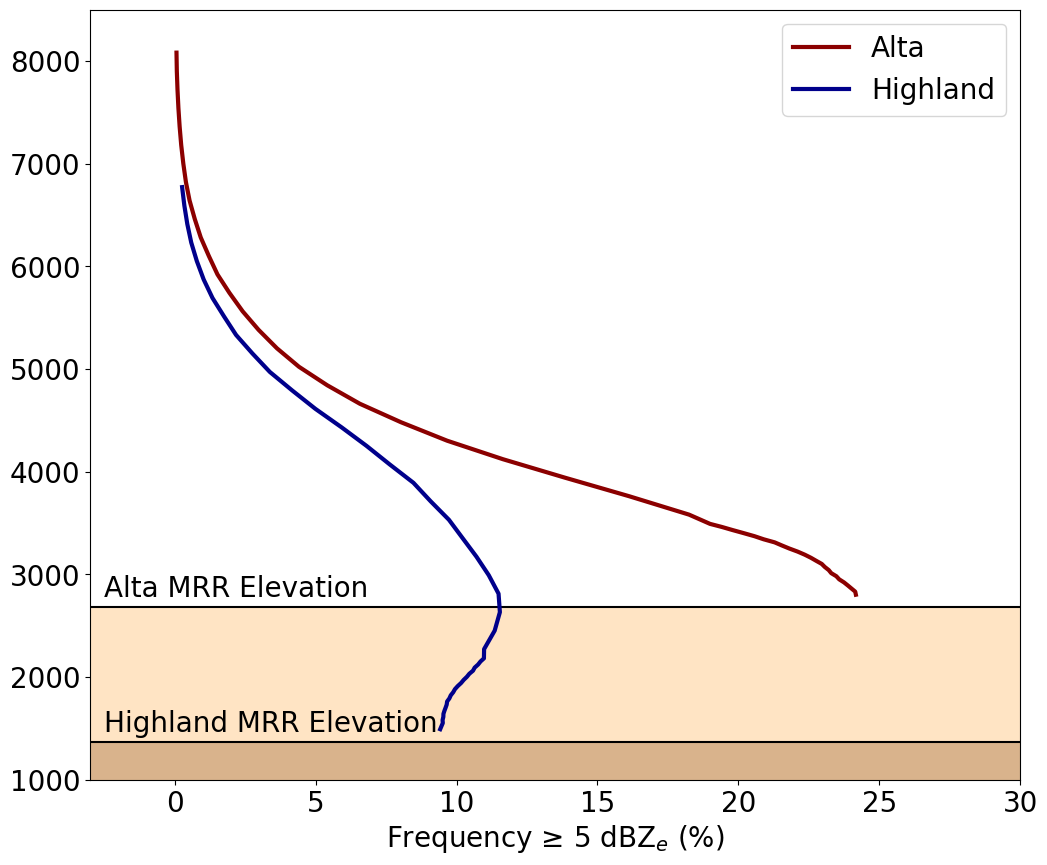

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(1, 1, facecolor='white', edgecolor='k',
                         figsize=(12,10), sharey=True)

# Stuff for the limits and plot settings
ylim_top = math.ceil(
    (alta180_SIVT.height_ASL.values[-1] + alta180_SIVT.range_gate) / 500) * 500
props = dict(boxstyle='square', facecolor='white', alpha=0.7, ec='gray')
xlabel = f'Frequency ≥ {int(Ze_max)} dBZ$_e$ (%)'

sl = slice(range_gate_start, range_gate_end)

# Plot the data
ax.plot(alta_freq_ALL[sl],     alta_hASL_ALL[sl],     linewidth=3, color='darkred',  label='Alta')
ax.plot(highland_freq_ALL[sl], highland_hASL_ALL[sl], linewidth=3, color='darkblue', label='Highland')

# Terrain shading — Alta (lighter) and Highland (darker)
ax.axhspan(bottom, alta180_ALL.MRR_elevation,     fc='bisque',   zorder=1)
ax.axhline(alta180_ALL.MRR_elevation,             color='black', zorder=1)
ax.text(-2.5, alta180_ALL.MRR_elevation + 100,
        'Alta MRR Elevation', fontsize=20, zorder=7, ha='left')

ax.axhspan(bottom, highland180_ALL.MRR_elevation, fc='#d9b38c',  zorder=2)
ax.axhline(highland180_ALL.MRR_elevation,         color='black', zorder=2)
ax.text(-2.5, highland180_ALL.MRR_elevation + 100,
        'Highland MRR Elevation', fontsize=20, zorder=7, ha='left')

# Set limits and ticks
ax.set_xlim(-3, 30)
ax.set_ylim(bottom, ylim_top)
ax.set_xticks(np.arange(0, 31, 5), labels=np.arange(0, 31, 5), fontsize=20)
ax.set_yticks(np.arange(bottom, 8001, 1000), labels=np.arange(bottom, 8001, 1000), fontsize=20)
ax.set_xlabel(xlabel, fontsize=20)
ax.legend(fontsize=20)

# Set y label on first axis
axes[0].set_ylabel('Height (m MSL)', fontsize=20)
plt.subplots_adjust(wspace=0.03)

# Save and show
plt.savefig(fig_dir + 'profile_geq_5_Highland_Alta_ALL.png',
            dpi=300, bbox_inches='tight')
plt.show()
